In [3]:
import arcpy
import os
from arcpy.sa import *
from datetime import datetime
import matplotlib.pyplot as plt #used to create visualization and maps
from matplotlib.patches import Polygon as MPLPolygon #used to draw polygon shapes on maps
from matplotlib.collections import LineCollection #useed to draw lines
import matplotlib.patches as mpatches #used to create legend items in matplotlib

print("All libraries imported")

ModuleNotFoundError: No module named 'arcpy'

In [ ]:
#creating configuration class to store all settings in one place
#it makes easier to change settings without searching through the code

class Config:
    workspace=r"C:\GEOS456\FinalProject"
    gdb_name="KananaskisWildlife"
    coordinates=arcpy.SpatialReference("NAD 1983 UTM Zone 11N")
    cell_size=25
    
arcpy.env.overwriteOutput = True    
arcpy.env.cellSize=Config.cell_size #this ensure consistent cell size across the script
arcpy.env.workspace=Config.workspace # Set the default workspace where ArcPy looks for data
arcpy.env.outputCoordinateSystem = Config.coordinates#ensure everything is in same coordinates

print("Everything is setup")

Everything is setup


### Messages

In [ ]:
#The following function helps print timestamp when script is executing
def log_message(message, level="INFO"):
    #the parameter messageand level prints something like INFO, SUCCESS, ERROR, 
    timestamp = datetime.now().strftime("%H:%M:%S") #get current time in hours, mins and secs
    print(f"[{timestamp}] [{level}] {message}")

print("Messages functions working")

Messages functions working


### Deleting existing gdb and creating a new one

In [ ]:
#path for new gdb
gdb_path = os.path.join(Config.workspace, f"{Config.gdb_name}.gdb")

#delete existing gdb
if arcpy.Exists(gdb_path):
    log_message(f"Deleting esisting {Config.gdb_name}.gdb")
    arcpy.management.Delete(gdb_path)

#Creating new gdb
log_message(f"Creating {Config.gdb_name}.gdb")
arcpy.management.CreateFileGDB(Config.workspace, Config.gdb_name)
log_message(f"Geodatabase created: {gdb_path}")

[13:52:12] [INFO] Deleting esisting KananaskisWildlife.gdb
[13:52:13] [INFO] Creating KananaskisWildlife.gdb
[13:52:13] [INFO] Geodatabase created: C:\GEOS456\FinalProject\KananaskisWildlife.gdb


In [ ]:
def visualize_map(gdb_path, layers_to_show, title="Study Area"):
    print(f"{title}")
    
    #creating matplotlib
    fig, ax = plt.subplots(figsize=(14, 10)) #size 14 inches wide, 10inches tall

    #styles and colors for features in the map
    styles = {
        # boundary
        'park_boundary': {
            'facecolor': '#E8E8E8',      # Light gray fill color
            'edgecolor': 'black',         # Black border
            'linewidth': 2.5,             # Thick border (2.5 points)
            'alpha': 0.6                  # 60% opaque (semi-transparent)
        },
        
        # Roads
        'roads': {
            'color': '#666666',           # Medium gray
            'linewidth': 0.8              # Thin lines
        },
        
        # Trails
        'trails': {
            'color': '#8B4513',           # Brown color
            'linewidth': 0.6,             # Very thin lines
            'linestyle': '--'             # Dashed line style
        },
        
        # Hydrology
        'hydrology': {
            'color': '#1E90FF',           # Dodger blue
            'linewidth': 1.2              # Medium thickness
        },
        
        # Habitats
        'habitats': {
            'facecolor': '#90EE90',       # Light green fill
            'edgecolor': '#228B22',       # Forest green outline
            'linewidth': 2,               # Thick outline
            'alpha': 0.7                  # 70% opaque
        },
        
        # Optimal routes
        'optimal_routes': {
            'color': '#FF0000',           # Pure red
            'linewidth': 3                # Very thick lines
        },
    }

    legend_elements=[] #list to store legend elements

    #loop through each layer and draw
    for layer_name in layers_to_show:
        
        #create a layer path to every feature in gdb
        layer_path=os.path.join(gdb_path, layer_name)

        #check if layer exist, if not, continue
        if not arcpy.Exists(layer_path):
            continue #skip and go to next

        desc=arcpy.Describe(layer_path)
        style=styles.get(layer_name, {})
        print(f"{layer_name}")

        #draw polygons
        if desc.shapeType == "Polygon":
            # Open a cursor to read each feature's geometry
            with arcpy.da.SearchCursor(layer_path, ["SHAPE@"]) as cursor:

                # Loop through each polygon feature
                for row in cursor:
                    polygon = row[0]  # Get the polygon geometry
                    
                    # Make sure polygon is not None
                    if polygon:
                        
                        # Polygons can have multiple parts
                        # Loop through each part
                        for part in range(polygon.partCount):
                            
                            # Get the array of points for this part
                            # Convert each point to (X, Y) tuple
                            # Filter out None points (can occur at part boundaries)
                            coords = [(pt.X, pt.Y) for pt in polygon.getPart(part) if pt]
                            
                            # Need at least 3 points to make a polygon
                            if len(coords) >= 3:
                                
                                # Create a matplotlib Polygon object
                                poly = MPLPolygon(
                                    coords,                           # List of (X, Y) coordinates
                                    facecolor=style.get('facecolor', 'lightgray'),  # Fill color
                                    edgecolor=style.get('edgecolor', 'black'),      # Border color
                                    linewidth=style.get('linewidth', 1),            # Border thickness
                                    alpha=style.get('alpha', 0.5)                   # Transparency
                                )
                                
                                # Add the polygon to the map
                                ax.add_patch(poly)
            
            # Add this layer to the legend
            legend_elements.append(
                mpatches.Patch(
                    facecolor=style.get('facecolor', 'lightgray'),
                    edgecolor=style.get('edgecolor', 'black'),
                    label=layer_name.replace('_', ' ').title()  # Format name nicely
                )
            )
        
       
        # DRAW LINES
    
        elif desc.shapeType == "Polyline":
            
            # List to store all line segments
            lines = []
            
            # Open cursor to read polyline geometries
            with arcpy.da.SearchCursor(layer_path, ["SHAPE@"]) as cursor:
                
                # Loop through each polyline feature
                for row in cursor:
                    polyline = row[0]  # Get the polyline geometry
                    
                    # Make sure polyline is not None
                    if polyline:
                        
                        # Polylines can have multiple parts (disconnected segments)
                        for part in range(polyline.partCount):
                            
                            # Get coordinates of points along the line
                            coords = [(pt.X, pt.Y) for pt in polyline.getPart(part) if pt]
                            
                            # Need at least 2 points to make a line
                            if len(coords) >= 2:
                                lines.append(coords)  # Add to lines list
            
            # If we have any lines, draw them all at once (more efficient)
            if lines:
                
                # Create a LineCollection (draws multiple lines efficiently)
                lc = LineCollection(
                    lines,                                  # List of line coordinate arrays
                    colors=style.get('color', 'black'),     # Line color
                    linewidths=style.get('linewidth', 1),   # Line thickness
                    linestyles=style.get('linestyle', 'solid')  # Line style (solid, dashed, etc.)
                )
                
                # Add all lines to the map at once
                ax.add_collection(lc)
                
                # Add this layer to the legend
                legend_elements.append(
                    mpatches.Patch(
                        color=style.get('color', 'black'),
                        label=layer_name.replace('_', ' ').title()
                    )
                )
    
    # SET MAP EXTENT (zoom level)
    # Use park boundary to determine map extent (how much area to show)
    park_path = os.path.join(gdb_path, 'kcountry')
    
    if arcpy.Exists(park_path):
        # Get the extent (bounding box) of the park boundary
        extent = arcpy.Describe(park_path).extent
        
        # Add a small buffer (2% of width/height) around the extent
        # This prevents features from being cut off at the edges
        buffer = 0.02
        x_buf = (extent.XMax - extent.XMin) * buffer
        y_buf = (extent.YMax - extent.YMin) * buffer
        
        # Set the X-axis limits (Easting coordinates)
        ax.set_xlim(extent.XMin - x_buf, extent.XMax + x_buf)
        
        # Set the Y-axis limits (Northing coordinates)
        ax.set_ylim(extent.YMin - y_buf, extent.YMax + y_buf)
    

    # FORMAT THE MAP
    
    # Keep aspect ratio equal (1 meter on X = 1 meter on Y)
    # This prevents distortion
    ax.set_aspect('equal')
    
    # Set the title at the top of the map
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    
    # Label the X-axis (Easting in meters)
    ax.set_xlabel('Easting (m)', fontsize=12)
    
    # Label the Y-axis (Northing in meters)
    ax.set_ylabel('Northing (m)', fontsize=12)
    
    # Format tick labels to show full numbers (not scientific notation)
    ax.ticklabel_format(style='plain', useOffset=False)
    
    # Add a grid for easier reading of coordinates
    ax.grid(True, alpha=0.3, linestyle='--')  # Semi-transparent dashed grid
    
    # ADD LEGEND
   
    if legend_elements:
        # Add legend in upper right corner
        ax.legend(
            handles=legend_elements,   # Legend items we created
            loc='upper right',          # Position
            fontsize=10,                # Text size
            framealpha=0.9              # Slightly transparent background
        )
    
    # ADD NORTH ARROW
    # Simple north arrow in upper right
    ax.text(
        0.97, 0.97,                     # Position (97% across, 97% up)
        'N',                            # Text to display
        transform=ax.transAxes,         # Use axes coordinates (0-1 instead of data coordinates)
        fontsize=20,                    # Large text
        fontweight='bold',              # Bold text
        ha='center',                    # Horizontal alignment: center
        va='top',                       # Vertical alignment: top
        bbox=dict(                      # Box around the N
            boxstyle='circle',          # Circular box
            facecolor='white',          # White background
            edgecolor='black',          # Black border
            linewidth=2                 # Thick border
        )
    )

    # Adjust spacing to prevent labels from being cut off
    plt.tight_layout()
    
    # Display the map in the notebook
    plt.show()
    
    # Create filename from title (replace spaces with underscores, make lowercase)
    #filename = f"{title.replace(' ', '_').lower()}.png"
    
    # Full path to save the image
    #filepath = os.path.join(Config.workspace, filename)
    
    # Save the figure as a PNG file
    # dpi=300 means high resolution (300 dots per inch - good for printing)
    # bbox_inches='tight' removes extra white space around the edges
    # facecolor='white' makes the background white (not transparent)
   # fig.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
    
    # Print confirmation message
    #print(f" Saved: {filename}\n")

# Confirm visualization function is loaded
print("Visualization function loaded")

Visualization function loaded


### Defining paths for features in workspace

[13:52:13] [INFO] Projecting Kananaskis boundary...
Study Area Boundary
kcountry


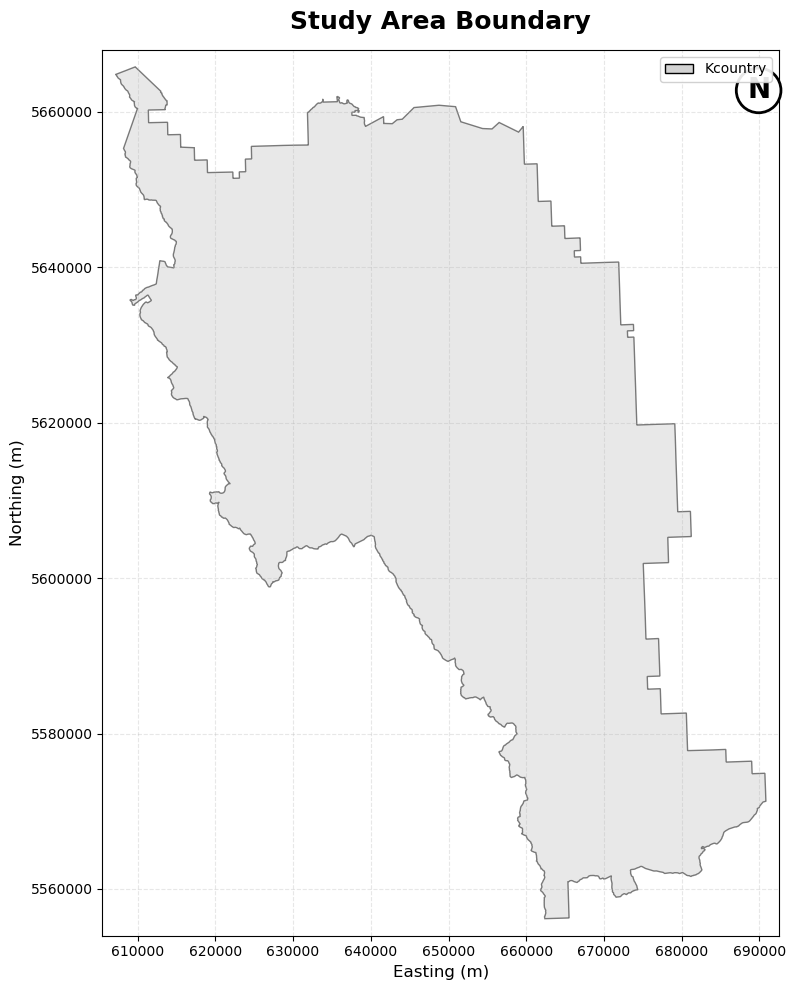

In [ ]:
kanaski_bound=os.path.join(Config.workspace, "Kananaskis", "Kcountry_bound.shp")
kanaski_bound_gdb=os.path.join(gdb_path, "kcountry")

#project boundary
log_message("Projecting Kananaskis boundary...")
arcpy.management.Project(kanaski_bound, kanaski_bound_gdb, Config.coordinates)

visualize_map(gdb_path, ["kcountry"], "Study Area Boundary")

### Clipping Vector Data to study Area

[13:52:14] [INFO] Processing {name}...

[13:52:16] [INFO] All vector data clipped
Clipped Data
roads


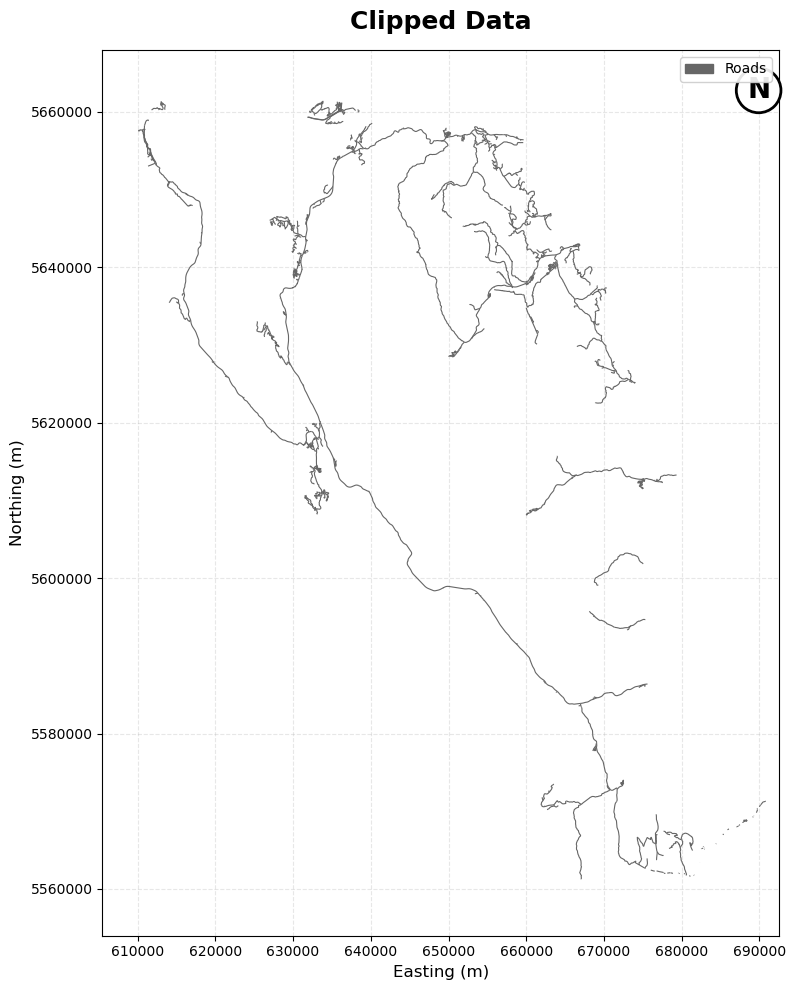

[13:52:16] [INFO] Processing {name}...

[13:52:20] [INFO] All vector data clipped
Clipped Data
roads
trails


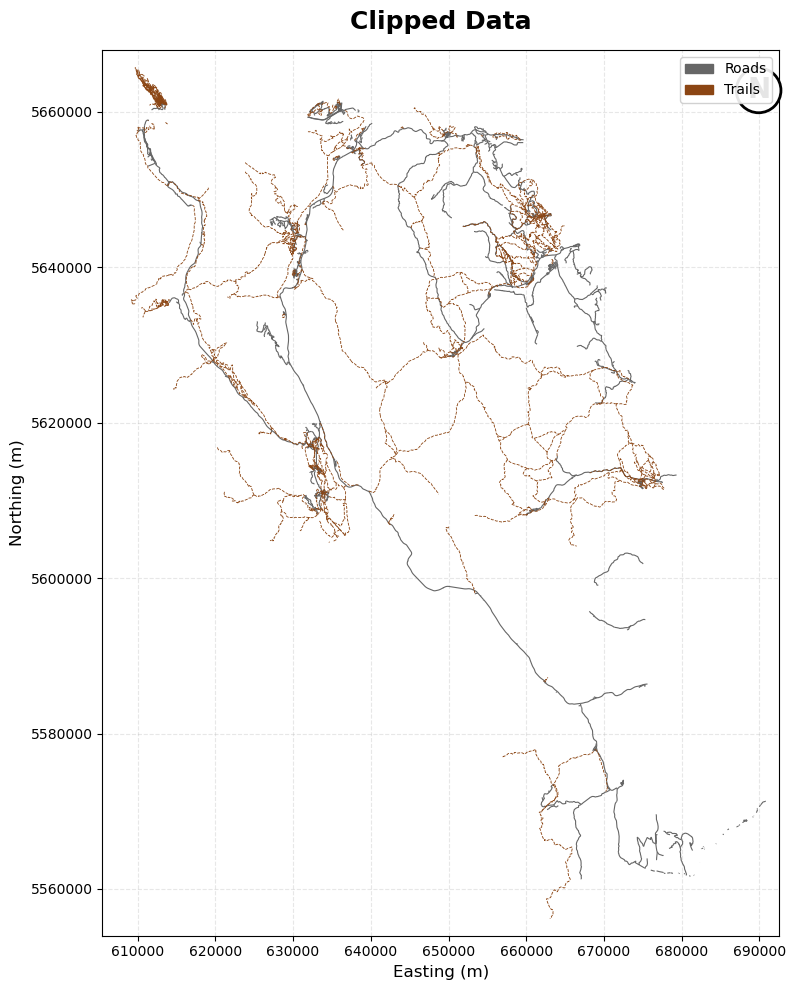

[13:52:22] [INFO] Processing {name}...

[13:52:24] [INFO] All vector data clipped
Clipped Data
roads
trails
hydrology


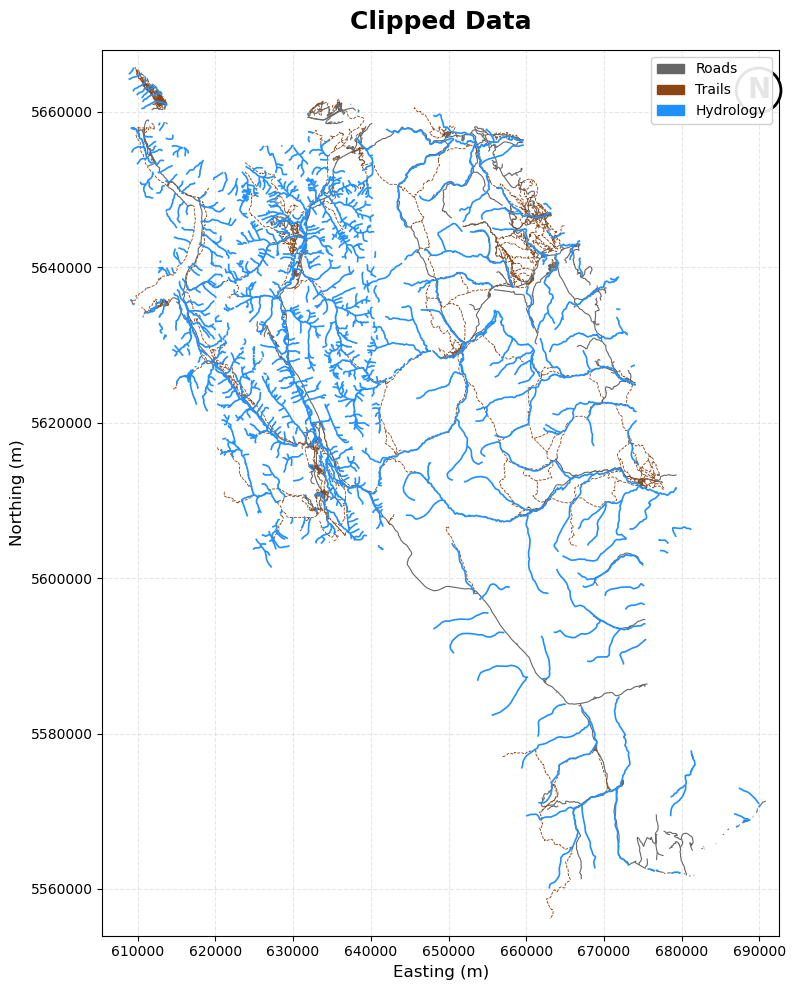

[13:52:26] [INFO] Processing {name}...

[13:52:28] [INFO] All vector data clipped
Clipped Data
roads
trails
hydrology
habitats


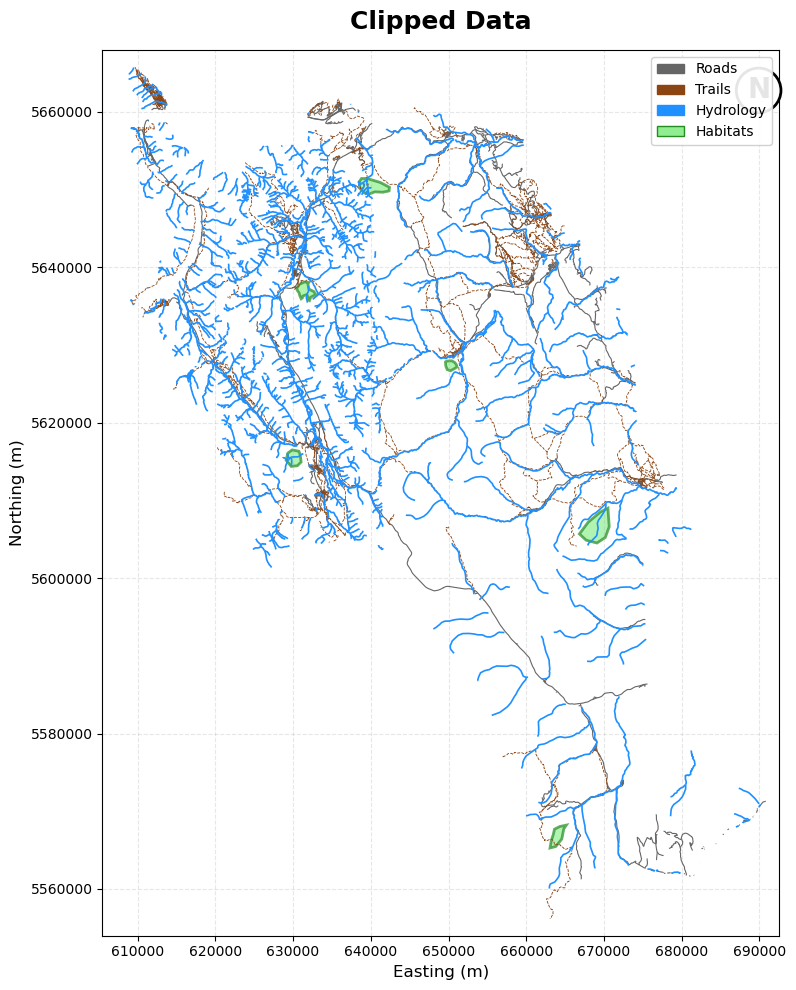

[13:52:31] [INFO] Processing {name}...

[13:52:33] [INFO] All vector data clipped
Clipped Data
roads
trails
hydrology
habitats


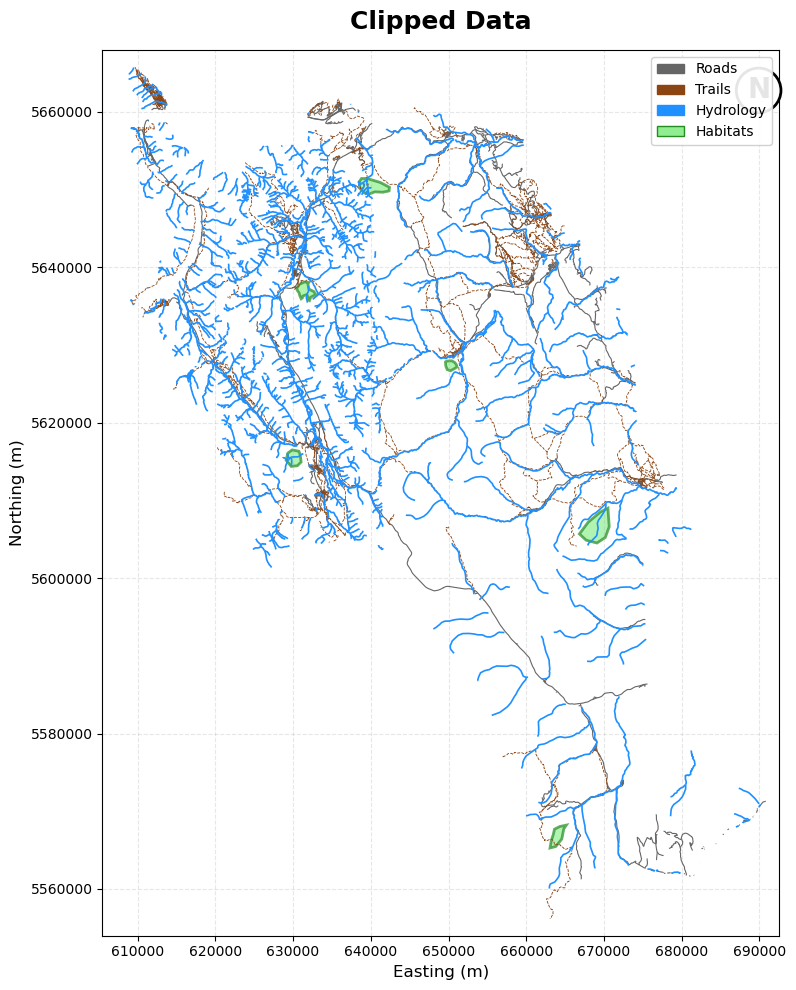

[13:52:36] [INFO] Processing {name}...

[13:52:37] [INFO] All vector data clipped
Clipped Data
roads
trails
hydrology
habitats


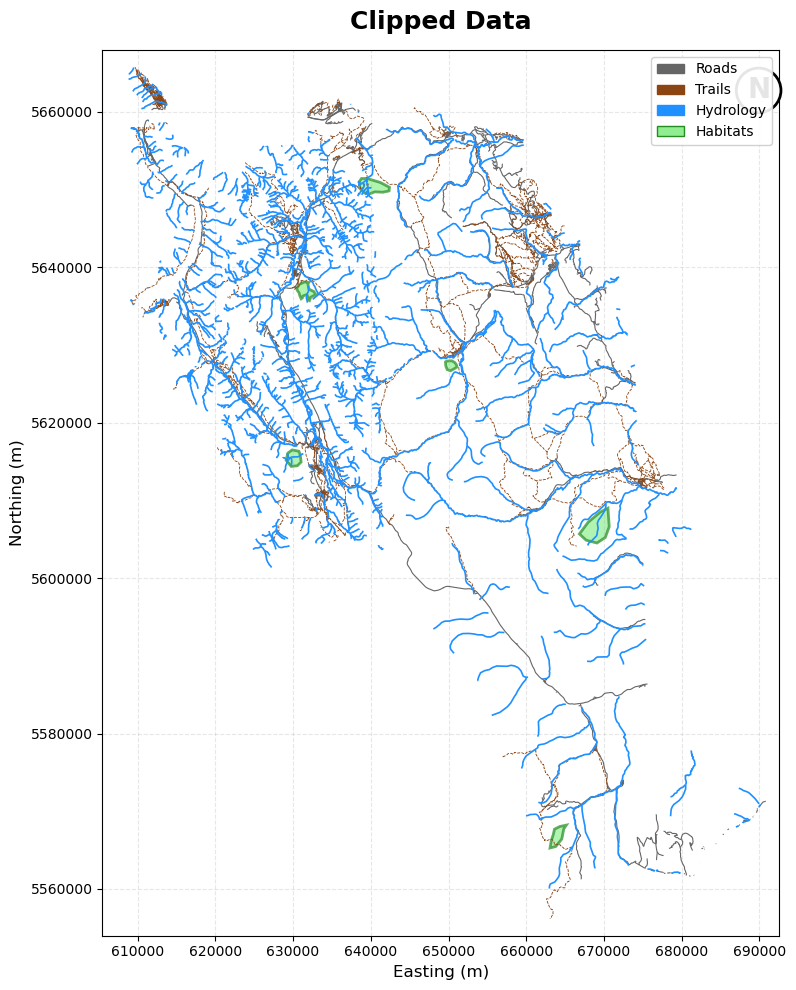

[13:52:40] [INFO] Processing {name}...

[13:52:41] [INFO] All vector data clipped
Clipped Data
roads
trails
hydrology
habitats


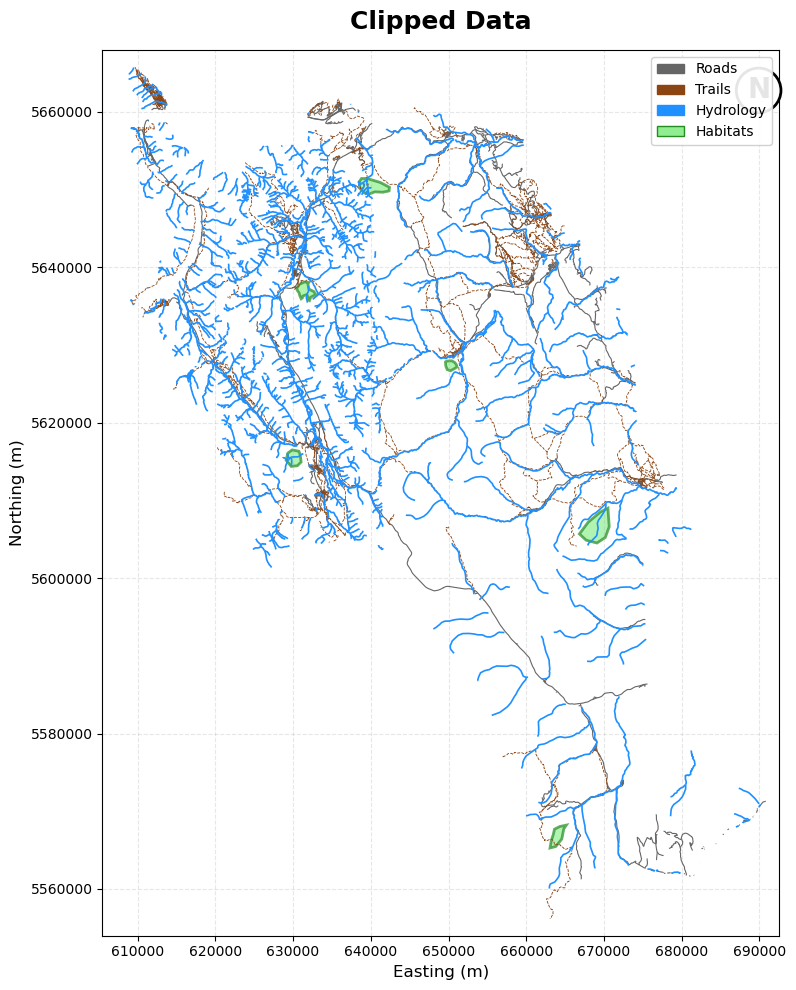

In [ ]:
vector_inputs = {
    'roads': os.path.join(Config.workspace, "Kananaskis", "Road.shp"),
    
    'trails': os.path.join(Config.workspace, "Kananaskis", "Trails.shp"),
    
    'hydrology': os.path.join(Config.workspace, "Kananaskis", "Hydro.shp"),
    
    'habitats': os.path.join(Config.workspace, "Wildlife", "Bear_Habitat.shp"),
    
    'esa': os.path.join(Config.workspace, "Wildlife", "ESA.shp"),
    
    'townships': os.path.join(Config.workspace, "ATS", "AB_Township.shp"),
    
    'nts_sheets': os.path.join(Config.workspace, "NTS", "NTS-50", "NTS50.shp")
}

#loop through each vector data and clip
for name, input_path in vector_inputs.items():
    log_message("Processing {name}...")
    
    #temporary projection layer to be deleted
    temp_proj=os.path.join(gdb_path, f"{name}_temp")

    #final output path
    output_fc=os.path.join(gdb_path, name)

    #project
    arcpy.management.Project(input_path, temp_proj, Config.coordinates)

    #clip
    arcpy.analysis.Clip(temp_proj, kanaski_bound_gdb, output_fc)

    #delete intermediate
    arcpy.management.Delete(temp_proj)
    print()

    log_message("All vector data clipped")

    #visualize
    visualize_map(gdb_path, ["kanaski_bound", "roads", "trails", "hydrology", "habitats"], "Clipped Data")
    

### DEM Processing

In [ ]:
#DEM
dem_input = os.path.join(Config.workspace, "dem", "ab_dem")
dem_output = os.path.join(gdb_path, "Dem")
log_message("Clipping DEM to park boundary...")
dem_clipped = arcpy.sa.ExtractByMask(dem_input, kanaski_bound_gdb)
dem_clipped.save(dem_output)
log_message("DEM clipped successfully")

[13:52:44] [INFO] Clipping DEM to park boundary...
[13:52:49] [INFO] DEM clipped successfully


### Landcover Processing

In [ ]:
#landcover shapefile input from the path
landcover_input = os.path.join(Config.workspace, "Landcover", "AB_Landcover.shp")

#temporary copy of landcover to be used for clipping
landcover_temp=os.path.join(gdb_path, "landcover_temp")

#final copy of landcover
landcover_output=os.path.join(gdb_path, "landcover")

#clipping landcover
log_message("Clipping landcover shapefile...")
arcpy.analysis.Clip(landcover_input, kanaski_bound_gdb, landcover_temp)

#converting landcover shapefile to shp
value_field="LC_class"

log_message(f"Converting to raster using field: {value_field}...")

#convert features to raster
arcpy.conversion.FeatureToRaster(
    landcover_temp,
    value_field,
    landcover_output,
    Config.cell_size
)

#Delete intermediate layer
arcpy.management.Delete(landcover_temp)

log_message("Landcover raster created")

[13:52:49] [INFO] Clipping landcover shapefile...
[13:53:02] [INFO] Converting to raster using field: LC_class...
[13:53:05] [INFO] Landcover raster created


### Create Cost Surface

#### 1. Terrain from slope

In [ ]:
#I will use the clipped data that we created in previous steps
dem_path = os.path.join(gdb_path, "Dem")  # Elevation raster
landcover_path = os.path.join(gdb_path, "landcover") # Landcover raster
roads_path = os.path.join(gdb_path, "roads") # Roads 
trails_path = os.path.join(gdb_path, "trails")# Trails 
hydrology_path = os.path.join(gdb_path, "hydrology")# Water features

log_message("Creating cost surface...")

#Slope
slope=arcpy.sa.Slope(dem_path, "DEGREE")

#Get the maximum slope value in the dataset
slope_max=float(slope.maximum)
print(f"Maximum Slope: {slope_max:.1f}")

#rescale slope to 0=10
#we want flat areas: 0=low cost, steep areas =high cost=10
transformation=arcpy.sa.TfLinear(
    0, #input minimum (0 =flat)
    slope_max, # input maximum (steepest slope)
    0, #output minimum (low cost for flat areas)
    10#output maximum (high cost for steep areas)
)

#apply transformation to rescale slope to 0 - 10
terrain_cost=arcpy.sa.RescaleByFunction(
    slope, #input raster
    transformation, #transformation function
    0,#minimum input value
    slope_max #maximum input value
)

terrain_cost_path=os.path.join(gdb_path, "Cost_terrain")
terrain_cost.save(terrain_cost_path)

log_message("Terrain cost created")

[13:53:05] [INFO] Creating cost surface...
Maximum Slope: 79.2
[13:53:12] [INFO] Terrain cost created


#### 2. Landcover reclassification

In [ ]:
log_message("Creating landcover cost surface...")

landcover_reclass = {
    1: 1,# Coniferous Forest =cost 1 (best)
    2: 1,  # Broadleaf Forest = cost 1 (best)
    3: 1,   # Mixed Forest = cost 1 (best)
    4: 2,  # Grassland = cost 2
    5: 3, # Shrubland = cost 3
    6: 6,   # Exposed Land = cost 6
    7: 7,  # Rock/Rubble = cost 7
    8: 8,  # Snow/Ice = cost 8
    9: 9,  # Agriculture = cost 9
    10: 10, # Water = cost 10 (can't traverse)
    11: 10 # Developed = cost 10 (avoid humans)
}

# Convert dictionary to list of [old, new] pairs
remap = arcpy.sa.RemapValue([[k, v] for k, v in landcover_reclass.items()])

landcover_cost = arcpy.sa.Reclassify(
    landcover_path,# Input raster
    "Value", # Field to reclassify (the cell values)
    remap,  # Remap table (old → new values)
    "NODATA" # What to do with values not in remap (set to NoData)
)

# Save landcover cost surface
landcover_cost_path = os.path.join(gdb_path, "Cost_landcover")
landcover_cost.save(landcover_cost_path)

log_message("Landcover cost created")

[13:53:12] [INFO] Creating landcover cost surface...
[13:53:16] [INFO] Landcover cost created


#### 3. Hydrology

In [ ]:
log_message("Creating hydrology proximity cost surface...")

# Limit processing to boundary area (speeds up processing)
arcpy.env.extent = kanaski_bound_gdb

#raster where each cell value = distance to nearest water in meters
hydro_dist = arcpy.sa.DistanceAccumulation(hydrology_path)

# This tells us the farthest any point is from water
hydro_max = float(hydro_dist.maximum)

# Print max distance
print(f"  Max distance to water: {hydro_max:.0f}m")

#create transformation for hydro 
transformation = arcpy.sa.TfLinear(
    hydro_max,  # Input minimum (far from water)
    0, # Input maximum (close to water)
    0,# Output minimum (low cost)
    10 # Output maximum (high cost)
)

# Apply transformation
hydro_cost = arcpy.sa.RescaleByFunction(
    hydro_dist,# Input (distance to water)
    transformation,# Transformation
    0, # Min input
    hydro_max # Max input
)

# Save hydrology cost surface
hydro_cost_path = os.path.join(gdb_path, "Cost_hydrology")
hydro_cost.save(hydro_cost_path)

# Log success
log_message("Hydrology cost created")

[13:53:17] [INFO] Creating hydrology proximity cost surface...
  Max distance to water: 49435m
[13:53:26] [INFO] Hydrology cost created


#### 4. Roads

In [ ]:
log_message("Creating roads proximity cost surface...")

# Calculate distance to roads
roads_dist = arcpy.sa.DistanceAccumulation(roads_path)

# Get maximum distance
roads_max = float(roads_dist.maximum)

print(f"  Max distance to roads: {roads_max:.0f}m")

# Close to roads = high cost (10), Far from roads = low cost (0)
transformation = arcpy.sa.TfLinear(
    0, # Input minimum (close to roads)
    roads_max,# Input maximum (far from roads)
    10, # Output minimum (high cost when close)
    0 # Output maximum (low cost when far)
)

# Apply transformation
roads_cost = arcpy.sa.RescaleByFunction(roads_dist, transformation, 0, roads_max)

# Save roads cost surface
roads_cost_path = os.path.join(gdb_path, "cost_roads")
roads_cost.save(roads_cost_path)

log_message("Roads cost created")

[13:53:26] [INFO] Creating roads proximity cost surface...
  Max distance to roads: 56694m
[13:53:35] [INFO] Roads cost created


#### 5. Trails

In [ ]:
log_message("Creating trails proximity cost surface...")

# Calculate distance to trails
trails_dist = arcpy.sa.DistanceAccumulation(trails_path)

# Get maximum distance
trails_max = float(trails_dist.maximum)
print(f"  Max distance to trails: {trails_max:.0f}m")

# Rescale
transformation = arcpy.sa.TfLinear(0, trails_max, 10, 0)
trails_cost = arcpy.sa.RescaleByFunction(trails_dist, transformation, 0, trails_max)

# Save trails cost surface
trails_cost_path = os.path.join(gdb_path, "cost_trails")
trails_cost.save(trails_cost_path)

log_message(" Trails cost created")

[13:53:36] [INFO] Creating trails proximity cost surface...
  Max distance to trails: 52507m
[13:53:45] [INFO]  Trails cost created


### Combine All Surfaces

In [ ]:
log_message("Combining all cost surfaces...")

# WSTable defines which rasters to combine and their weights
# Format: [[raster_path, "VALUE", weight], ...]

ws_table = arcpy.sa.WSTable([
    [terrain_cost_path, "VALUE", 1], # Terrain cost, weight = 1
    [landcover_cost_path, "VALUE", 1],# Landcover cost, weight = 1
    [hydro_cost_path, "VALUE", 1], # Hydrology cost, weight = 1
    [roads_cost_path, "VALUE", 1],# Roads cost, weight = 1
    [trails_cost_path, "VALUE", 1]# Trails cost, weight = 1
])

# Perform weighted sum
combined_cost = arcpy.sa.WeightedSum(ws_table)

# Save combined cost surface
combined_cost_path = os.path.join(gdb_path, "cost_combined")
combined_cost.save(combined_cost_path)
log_message("All cost surfaces created")

[13:53:46] [INFO] Combining all cost surfaces...
[13:53:47] [INFO] All cost surfaces created


In [ ]:
print(arcpy.management.GetRasterProperties(
    combined_cost_path, "VALUETYPE"
))

9


### Calculating Statistics for combined cost surface

In [ ]:
# # Get statistics of combined cost surface
# # Get min, max, and mean values to understand cost distribution
# combined_min = float(combined_cost.minimum)
# combined_max = float(combined_cost.maximum)
# combined_mean = float(combined_cost.mean)

# # Print statistics
# print(f"  Combined cost statistics:")
# print(f"    Min: {combined_min:.2f}")       # Lowest cost in study area
# print(f"    Max: {combined_max:.2f}")       # Highest cost in study area
# print(f"    Mean: {combined_mean:.2f}")     # Average cost

# # Log final success
# log_message("All cost surfaces created and combined", "SUCCESS")

### Calculating optimal wildlife corridors

In [ ]:
#path to habitat polygons (the patches we want to connect)
habitats_path = os.path.join(gdb_path, "habitats")

combined_cost_path = os.path.join(gdb_path, "cost_combined")

log_message("Converting habitat polygons to centroids...")

# Path for temporary habitat centroids
habitat_centroids = os.path.join(gdb_path, "habitat_centroids_temp")

# FeatureToPoint creates a point at the center of each polygon
# INSIDE parameter ensures point is inside the polygon (not outside)
arcpy.management.FeatureToPoint(
    habitats_path, # Input: habitat polygons
    habitat_centroids,# Output: habitat centroids (points)
    "INSIDE" # Ensure points are inside polygons
)

log_message("Created habitat centroids")

[14:17:11] [INFO] Converting habitat polygons to centroids...
[14:17:12] [INFO] Created habitat centroids


#### Calculate cost distance

In [ ]:
log_message("Calculating cost distance from habitats...")

#it will create cost distance raster and backlink raster
cost_distance = arcpy.sa.CostDistance(
    habitat_centroids, # Source points (habitat centroids)
    combined_cost_path,# Cost surface to traverse
    out_backlink_raster=os.path.join(gdb_path, "cost_backlink_temp")  # Direction raster
)
# Save cost distance raster
cost_dist_path = os.path.join(gdb_path, "cost_distance_temp")
cost_distance.save(cost_dist_path)


log_message("Cost distance calculated")

[14:21:14] [INFO] Calculating cost distance from habitats...
[14:21:38] [INFO] Cost distance calculated


### Calculate least cost path between habitats

[14:38:00] [INFO] Calculating least_cost path between habitats...
Connecting  habitat patches...
[14:39:41] [SUCCESS]   ✓ Generated 14 path segments
[14:39:41] [INFO] Converting paths to polylines...
[14:40:01] [SUCCESS]   ✓ Converted 14 paths
[14:40:01] [INFO] Merging all path segments...
[14:40:02] [SUCCESS]   ✓ Merged all segments
[14:40:02] [INFO] Clipping routes to park boundary...
[14:40:04] [SUCCESS]   ✓ Routes clipped to park boundary
[14:40:04] [INFO] Calculating route statistics...

  Results:
    Corridor segments: 14
    Total corridor length: 0.00 km
[14:40:06] [SUCCESS] ✓ Optimal routes calculated
[14:40:06] [INFO] Cleaning up intermediate data...
[14:41:58] [SUCCESS]   ✓ Deleted 32 temporary files
Step 7 - Optimal Wildlife Corridors
habitats
optimal_routes


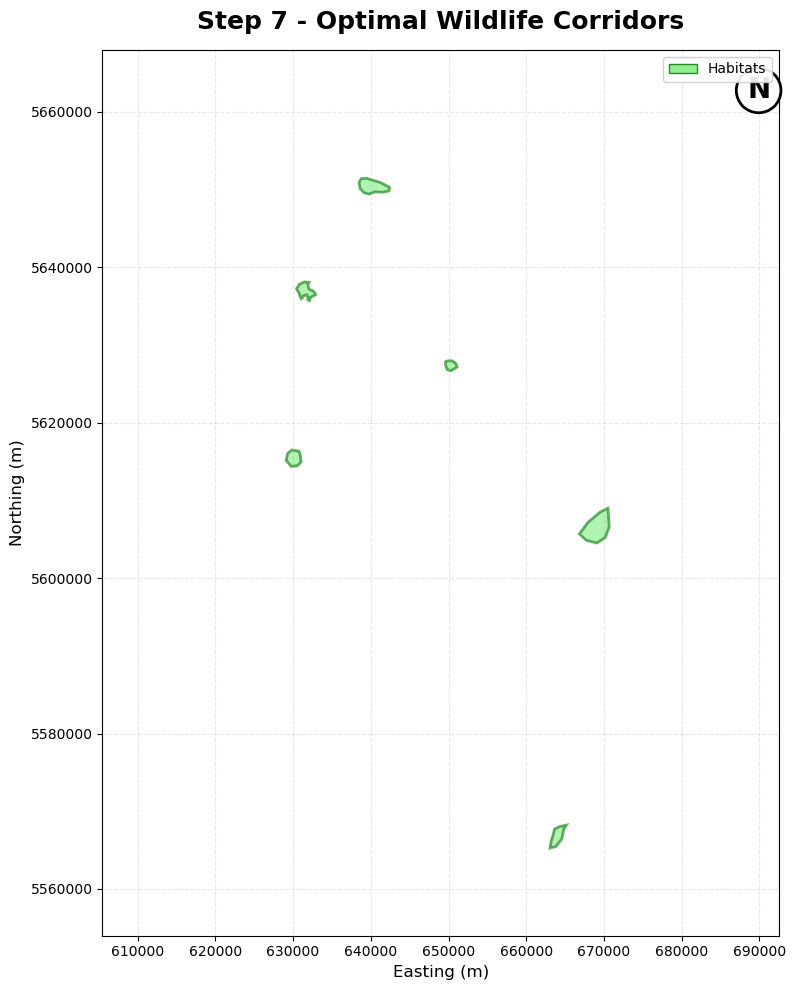

In [ ]:
log_message("Calculating least_cost path between habitats...")

#list to store habitat information
habitats_list=[]

# Open cursor to read centroid coordinates and IDs
with arcpy.da.SearchCursor(habitat_centroids, ["SHAPE@XY", "OBJECTID"]) as cursor:
    # Loop through each habitat centroid
    for row in cursor:
        # Create dictionary with coordinates and ID
        habitats_list.append({
            'coords': row[0],      # SHAPE@XY gives (X, Y) tuple
            'oid': row[1]          # OBJECTID is unique ID
        })

# Print info about how many patches we're connecting
print("Connecting  habitat patches...")

# ---------------------------------------------------------------------
# Calculate paths between all unique pairs
# ---------------------------------------------------------------------
# We use nested loops to create all unique pairs
# For example, if we have habitats A, B, C:
#   - Calculate path from A to B
#   - Calculate path from A to C  
#   - Calculate path from B to C
# (We don't calculate B to A because it's the same as A to B)

# List to store temporary path rasters
path_rasters = []

# Counter for number of paths created
pair_count = 0

# Outer loop: iterate through each habitat (i = starting habitat)
for i in range(len(habitats_list)):
    
    # Inner loop: iterate through remaining habitats (j = destination habitat)
    # Start at i+1 to avoid duplicate pairs (A→B is same as B→A)
    for j in range(i + 1, len(habitats_list)):
        
        # Get coordinates of destination habitat
        dest_coords = habitats_list[j]['coords']
        
        # Create a Point object from coordinates
        dest_point = arcpy.Point(dest_coords[0], dest_coords[1])
        
        # Create a PointGeometry object with spatial reference
        dest_geom = arcpy.PointGeometry(dest_point, Config.coordinates)
        
        try:
            # CostPath finds the least-cost route from destination to source
            # It uses the cost distance and backlink rasters
            cost_path = arcpy.sa.CostPath(
                dest_geom,                                          # Destination point
                cost_dist_path,                                     # Cost distance raster
                os.path.join(gdb_path, "cost_backlink_temp")       # Backlink raster
            )
            
            # Create unique name for this path raster
            path_temp = os.path.join(gdb_path, f"path_{i}_{j}_temp")
            
            # Save the path raster
            cost_path.save(path_temp)
            
            # Add to list of path rasters
            path_rasters.append(path_temp)
            
            # Increment counter
            pair_count += 1
            
        except Exception as e:
            # If path calculation fails (rare), print warning and continue
            print(f"  Warning: Could not create path {i}→{j}")
            # Continue to next pair instead of stopping the whole process

# Log how many paths were created
log_message(f"  ✓ Generated {pair_count} path segments", "SUCCESS")

# =========================================================================
# STEP 7D: CONVERT RASTER PATHS TO POLYLINES (VECTOR)
# =========================================================================
# The cost paths are currently rasters (grid of cells)
# We need to convert them to vector polylines for better visualization

log_message("Converting paths to polylines...")

# List to store polyline paths
all_polylines = []

# Loop through each path raster
for path_raster in path_rasters:
    
    # Create output name for polyline version
    # Replace "_temp" with "_line_temp"
    polyline_temp = path_raster.replace("_temp", "_line_temp")
    
    # Convert raster to polyline
    arcpy.conversion.RasterToPolyline(
        path_raster,        # Input raster path
        polyline_temp,      # Output polyline
        "ZERO",             # Background value (areas that are NOT the path)
        0,                  # Minimum dangle length
        "SIMPLIFY"          # Simplify geometry (remove unnecessary vertices)
    )
    
    # Add to list of polylines
    all_polylines.append(polyline_temp)

# Log success
log_message(f"  ✓ Converted {len(all_polylines)} paths", "SUCCESS")

# =========================================================================
# STEP 7E: MERGE ALL PATHS INTO SINGLE FEATURE CLASS
# =========================================================================
# Now we have many separate polyline files
# Merge them all into one feature class

log_message("Merging all path segments...")

# Path for merged routes (still temporary)
optimal_routes_temp = os.path.join(gdb_path, "optimal_routes_temp")

# Merge all polylines into one feature class
# Merge combines multiple feature classes into one
arcpy.management.Merge(
    all_polylines,          # List of input polylines
    optimal_routes_temp     # Output merged feature class
)

# Log success
log_message(f"  ✓ Merged all segments", "SUCCESS")

# =========================================================================
# STEP 7F: CLIP ROUTES TO PARK BOUNDARY
# =========================================================================
# Some routes might extend slightly outside park boundary due to raster processing
# Clip them to ensure all routes are within the park

log_message("Clipping routes to park boundary...")

# Path for final routes
optimal_routes_final = os.path.join(gdb_path, "optimal_routes")

# Clip merged routes to park boundary
arcpy.analysis.Clip(
    optimal_routes_temp,        # Input routes
    kanaski_bound_gdb,          # Clip feature (park boundary)
    optimal_routes_final        # Output clipped routes
)

# Log success
log_message(f"  ✓ Routes clipped to park boundary", "SUCCESS")

# =========================================================================
# STEP 7G: CALCULATE ROUTE LENGTH
# =========================================================================
# Add a field with the length of each route segment in meters

log_message("Calculating route statistics...")

# AddGeometryAttributes adds fields with geometric properties
# "LENGTH_GEODESIC" calculates accurate length in meters
# "METERS" specifies the unit
arcpy.management.AddGeometryAttributes(
    optimal_routes_final,       # Feature class to add fields to
    "LENGTH_GEODESIC",          # Type of geometry attribute
    "METERS"                    # Length unit
)

# ---------------------------------------------------------------------
# Sum all route lengths to get total corridor length
# ---------------------------------------------------------------------

# Initialize total length variable
total_length_m = 0

# Open cursor to read length values
# LENGTH_GEO is the field created by AddGeometryAttributes
with arcpy.da.SearchCursor(optimal_routes_final, ["LENGTH_GEO"]) as cursor:
    # Loop through each route segment
    for row in cursor:
        # Add this segment's length to total
        total_length_m += row[0]

# Convert meters to kilometers for easier reading
total_length_km = total_length_m / 1000

# ---------------------------------------------------------------------
# Print summary statistics
# ---------------------------------------------------------------------
print(f"\n  Results:")
#print(f"    Habitat patches: {habitat_count}")                  # Number of patches connected
print(f"    Corridor segments: {pair_count}")                   # Number of route segments
print(f"    Total corridor length: {total_length_km:.2f} km")  # Total length of all routes

# Log success
log_message("✓ Optimal routes calculated", "SUCCESS")

# =========================================================================
# STEP 7H: CLEANUP INTERMEDIATE DATA
# =========================================================================
# Delete all temporary files to keep geodatabase clean

log_message("Cleaning up intermediate data...")

# List of all temporary files to delete
cleanup_list = [
    habitat_centroids,                                  # Habitat centroids (temp)
    cost_dist_path,                                     # Cost distance raster (temp)
    os.path.join(gdb_path, "cost_backlink_temp"),     # Backlink raster (temp)
    optimal_routes_temp                                 # Merged routes before clipping (temp)
] + path_rasters + all_polylines  # Add all individual path rasters and polylines

# Counter for deleted files
deleted = 0

# Loop through cleanup list
for item in cleanup_list:
    # Check if file exists
    if arcpy.Exists(item):
        # Delete it
        arcpy.management.Delete(item)
        # Increment counter
        deleted += 1

# Log how many files were deleted
log_message(f"  ✓ Deleted {deleted} temporary files", "SUCCESS")

# =========================================================================
# VISUALIZE FINAL ROUTES
# =========================================================================
# Show map with park boundary, habitats, and optimal routes

visualize_map(
    gdb_path,                               # Geodatabase path
    ['park_boundary', 'habitats', 'optimal_routes'],  # Layers to show
    "Step 7 - Optimal Wildlife Corridors"   # Map title
)